# Bank Marketing — Binary Classification

## Workflow Description

The notebook follows these numbered steps, which are referenced in the whole notebook:

1. **Global Constants, Reproducibility, Imports**: set seeds, define constants, import libraries.
2. **Load Data**: load train/test/submission from local, Kaggle, or Colab.
3. **Missing Value Check**: confirm data quality before any modelling.
4. **Exploratory Data Analysis (EDA)**: statistical summary, correlation matrix, target distribution, target rate by categorical feature.
5. **Feature Engineering**: add and evaluate engineered features; keep only those that improve OOF AUC, if any (!).
6. **Preprocessing Pipelines**: skewness analysis, column definitions, custom transformers, `build_preprocessor()`.
7. **Prepare X / y**: assemble final feature matrices for modelling.
8. **CV Helper**: `run_cv()` utility for stratified k-fold evaluation.
9. **Baseline: Random Forest**: untuned RF on a hold-out split, then full CV (anchor for ablation).
10. **XGBoost: Hyperparameter Tuning + CV**: GridSearchCV on a 30 % subsample, then full CV.
11. **LightGBM: Hyperparameter Tuning + CV**: same pattern as XGBoost.
12. **Random Forest: Hyperparameter Tuning + CV**: tuned RF for use in stacking.
13. **Stacking Ensemble**: Logistic Regression meta-learner on OOF predictions.
14. **Final Model Comparison Table**: side-by-side CV AUC for all models.
15. **Ablation Study**: step-by-step contribution of each decision (FE, tuning, naive vs learned ensemble, RF inclusion).
16. **Submission File**: generate `submission.csv` from the best model.

---
## 1. Global Constants, Reproducibility, Imports

In [ ]:
import random
import numpy as np

# global constants
RANDOM_SEED   = 42
N_SPLITS      = 5          # number of CV folds
TEST_SIZE     = 0.20       # train/val split for the baseline RF
N_JOBS        = -1         # use all cores where supported
SAVE_DIR      = "/content/drive/MyDrive/machine learning/saved_models/"  # Colab Drive path to save artefacts (pipelines, scores, OOF preds, test preds)

# reproducibility
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"RANDOM_SEED={RANDOM_SEED}  N_SPLITS={N_SPLITS}  TEST_SIZE={TEST_SIZE}")

RANDOM_SEED=42  N_SPLITS=5  TEST_SIZE=0.2


In [45]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    GridSearchCV, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, TargetEncoder
)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("All imports OK.")

All imports OK.


---
## 2. Load Data

Kaggle provided the following datasets:

- `train.csv`: Training data with features and target variable.
- `test.csv`: Test data without the target variable (used for the final submission).
- `sample_submission.csv`: Required submission format.

Choose whether to run in local, Kaggle, or Colab by setting the flags below.

In [ ]:
# Choose the environment where you want to run the code by setting the corresponding flag to `True` and the others to `False`. The code will load the datasets from the appropriate location based on your choice.
local  = False
kaggle = False
colab  = True

if local:
    train      = pd.read_csv("train.csv")
    test       = pd.read_csv("test.csv")
    submission = pd.read_csv("sample_submission.csv")

elif kaggle:
    base = "/kaggle/input/competitions/playground-series-s5e8/"
    train      = pd.read_csv(base + "train.csv")
    test       = pd.read_csv(base + "test.csv")
    submission = pd.read_csv(base + "sample_submission.csv")

elif colab:
    from google.colab import drive
    drive.mount("/content/drive")
    base = "/content/drive/MyDrive/machine learning/"
    train      = pd.read_csv(base + "train.csv")
    test       = pd.read_csv(base + "test.csv")
    submission = pd.read_csv(base + "sample_submission.csv")

# Drop non-informative id column
train.drop("id", axis=1, inplace=True)
test.drop("id",  axis=1, inplace=True)

print("Train shape:", train.shape)
print("Test shape: ", test.shape)
train.head(5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train shape: (750000, 17)
Test shape:  (250000, 16)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


The shape of the datasets:
- **Train**: (750k, 18) — features + target.
- **Test**: (250k, 17) — features only (target withheld for leaderboard evaluation).
- **Submission**: (250k, 2) — ID + predicted probability.

---
## 3. Missing Value Check

In [ ]:
# check if there are any missing values in train and test datasets
if train.isnull().sum().sum() == 0 and test.isnull().sum().sum() == 0:
    print("No missing values in train and test datasets.")

No missing values in train and test datasets.


---
## 4. Exploratory Data Analysis (EDA)

Check data types, unique values and meaning, along with correlations between features and with the target variable.

In [ ]:
# Statistical summary: covers dtypes, unique counts, and distribution moments
train.describe(include="all")

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,750000.000000,750000,750000,750000,750000,750000.000000,750000,750000,750000,750000.000000,750000,750000.000000,750000.000000,750000.000000,750000.000000,750000,750000.000000
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,NaN
top,NaN,management,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,NaN
freq,NaN,175541,480759,401683,737151,NaN,411288,645023,486655,NaN,228411,NaN,NaN,NaN,NaN,672450,NaN
mean,40.926395,NaN,NaN,NaN,NaN,1204.067397,NaN,NaN,NaN,16.117209,NaN,256.229144,2.577008,22.412733,0.298545,NaN,0.120651
std,10.098829,NaN,NaN,NaN,NaN,2836.096759,NaN,NaN,NaN,8.250832,NaN,272.555662,2.718514,77.319998,1.335926,NaN,0.325721
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,1.000000,1.000000,-1.000000,0.000000,NaN,0.000000
25%,33.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,9.000000,NaN,91.000000,1.000000,-1.000000,0.000000,NaN,0.000000
50%,39.000000,NaN,NaN,NaN,NaN,634.000000,NaN,NaN,NaN,17.000000,NaN,133.000000,2.000000,-1.000000,0.000000,NaN,0.000000
75%,48.000000,NaN,NaN,NaN,NaN,1390.000000,NaN,NaN,NaN,21.000000,NaN,361.000000,3.000000,-1.000000,0.000000,NaN,0.000000


**Bank client data**
- Age (numeric)
- Job (categorical): job descriptions
- Marital (categorical): marital status
- Education (categorical): education level
- Default (categorical): has credit in default?
- Balance (numeric): average yearly balance in euros
- Housing (categorical): has housing loan?
- Loan (categorical): has personal loan?

**Last contact of the current campaign**
- Contact (categorical): contact communication type
- Day (numeric): last contact day of the month
- Month (categorical): last contact month of the year
- Duration (numeric): last contact duration, in seconds

**Previous campaign attributes**
- Campaign (numeric): number of contacts during this campaign (includes last contact)
- Pdays (numeric): days since last contact from a previous campaign (-1 = never contacted)
- Previous (numeric): number of contacts before this campaign
- Poutcome (categorical): outcome of the previous marketing campaign

**Target variable**
- Y (binary): has the client subscribed a term deposit? (yes / no)

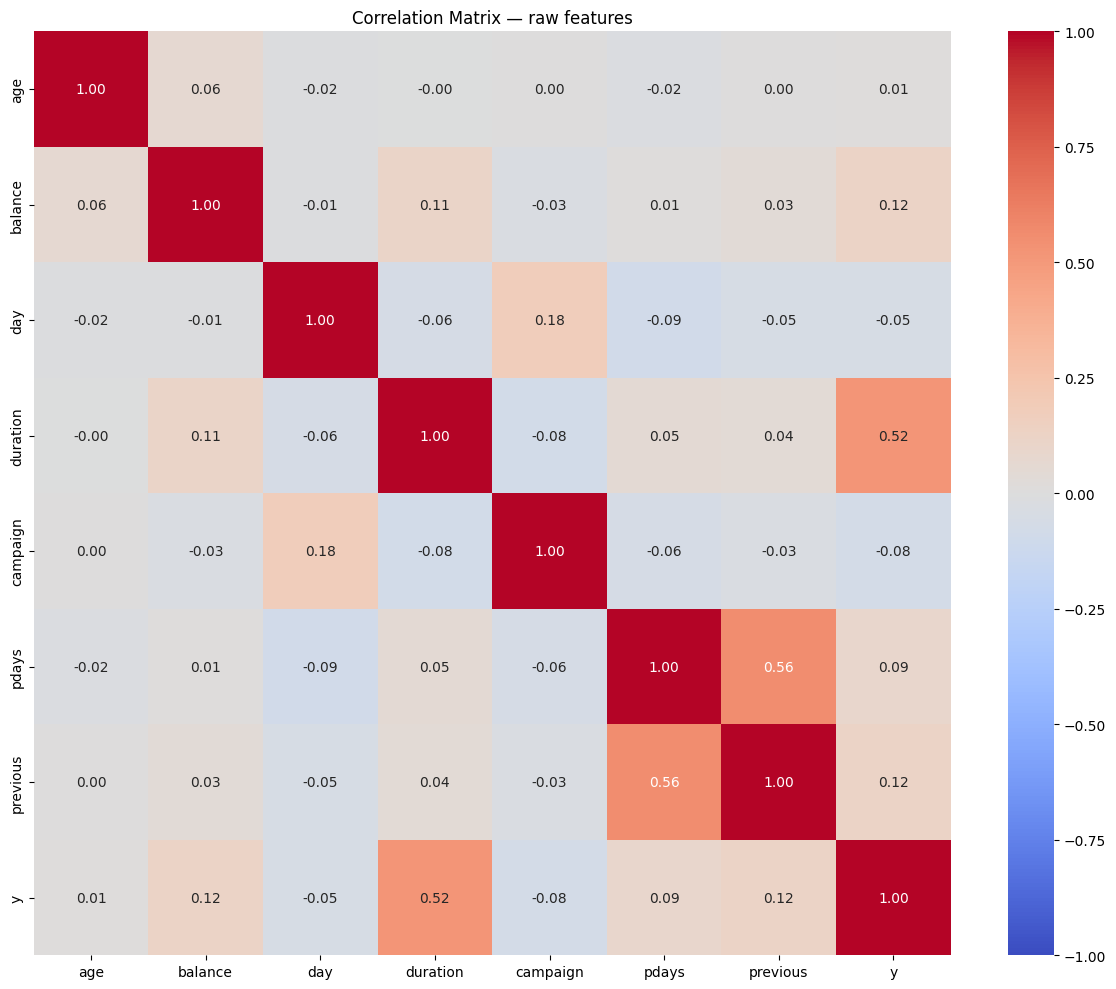

In [ ]:
# 4a. Correlation matrix (numerical features)
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12, 10))
sns.heatmap(train[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix — raw features")
plt.tight_layout()
plt.show()

We see that duration is definitely the highest correlated feature with the target variable, which is a common pattern in marketing datasets: the longer the customer is on the phone, the more likely they are to subscribe.

In [ ]:
# 4b. Target distribution
print("Target distribution (%)")
print((train["y"].value_counts(normalize=True) * 100).round(2))

Target distribution (%)
y
0    87.93
1    12.07
Name: proportion, dtype: float64


---
## 5. Feature Engineering

### 5a. Candidate feature definitions

We test several candidate engineered features and select only those that improve
OOF AUC on a quick Random Forest baseline. Keeping features that hurt performance
is a common source of hidden degradation.

Candidates:
- `previously_contacted` — binary flag for `pdays != -1`.
- `job_education` — interaction string between job and education level.
- `duration_balance` — product of call duration and account balance.
- `contact_rate` — contacts this campaign divided by (previous contacts + 1); captures call intensity relative to history.
- `balance_per_age` — balance normalised by age; a rough wealth proxy.
- `short_call` — binary flag for calls under 60 s (likely hang-ups, strong negative signal).
- `high_campaign` — binary flag for clients contacted more than 5 times this campaign (fatigue signal).

In [51]:
def add_features_v1(df):
    """Original feature set (v1) — for ablation comparison."""
    df = df.copy()
    df["previously_contacted"] = (df["pdays"] != -1).astype(int)
    df["job_education"]        = df["job"].astype(str) + "_" + df["education"].astype(str)
    df["duration_balance"]     = df["duration"] * df["balance"]
    return df


def add_features_v2(df):
    """
    Revised feature set (v2) — drops duration_balance (noisy product of
    two skewed features) and adds more targeted binary / ratio features
    that capture domain knowledge about call campaigns.
    """
    df = df.copy()

    # Boolean flag: was client ever contacted before this campaign?
    df["previously_contacted"] = (df["pdays"] != -1).astype(int)

    # job × education
    df["job_education"] = df["job"].astype(str) + "_" + df["education"].astype(str)

    # Call intensity: how many new contacts relative to historic contacts
    # Avoids division by zero via +1 smoothing
    df["contact_rate"] = df["campaign"] / (df["previous"] + 1) # campaign = current contacts, previous = historic contacts

    # Wealth proxy: balance scaled by age
    df["balance_per_age"] = df["balance"] / (df["age"] + 1)

    # Very short calls are nearly always immediate hang-ups --> strong negative signal
    df["short_call"] = (df["duration"] < 60).astype(int)

    # Clients contacted many times this campaign show fatigue / resistance
    df["high_campaign"] = (df["campaign"] > 5).astype(int)

    return df


train_fe_v1 = add_features_v1(train)
train_fe_v2 = add_features_v2(train)
test_fe_v2  = add_features_v2(test)

print("v1 shape:", train_fe_v1.shape)
print("v2 shape:", train_fe_v2.shape)

v1 shape: (750000, 20)
v2 shape: (750000, 23)


### 5b. Feature Engineering Evaluation

We run a quick 3-fold CV on a 30 % subsample with a lightweight Random Forest to
compare: raw features, v1 FE, and v2 FE. The winner is used for all subsequent
modelling.

In [52]:
TARGET = "y"

# Raw column lists (no FE)
RAW_NUM_COLS = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
RAW_CAT_COLS = ["job", "marital", "education", "default", "housing",
                "loan", "contact", "month", "poutcome"]

# v1 column lists
V1_NUM_COLS = RAW_NUM_COLS + ["previously_contacted", "duration_balance"]
V1_CAT_COLS = RAW_CAT_COLS + ["job_education"]

# v2 column lists
V2_NUM_COLS = RAW_NUM_COLS + [
    "previously_contacted", "contact_rate", "balance_per_age",
    "short_call", "high_campaign"
]
V2_CAT_COLS = RAW_CAT_COLS + ["job_education"]


def quick_preprocessor(num_cols, cat_cols):
    """Minimal preprocessor for FE evaluation: scale numerics, OHE categoricals."""
    return ColumnTransformer(
        transformers=[
            ("num",
             Pipeline([
                 ("impute", SimpleImputer(strategy="median")),
                 ("scale",  StandardScaler()),
             ]),
             num_cols),
            ("cat",
             Pipeline([
                 ("impute", SimpleImputer(strategy="most_frequent")),
                 ("encode", OneHotEncoder(
                     handle_unknown="ignore", sparse_output=False, drop="first"
                 )),
             ]),
             cat_cols),
        ],
        remainder="drop",
    )


def fe_score(X_df, num_cols, cat_cols, label):
    """Return mean 3-fold CV AUC on a 30 % subsample."""
    X_sample, _, y_sample, _ = train_test_split(
        X_df[num_cols + cat_cols], X_df[TARGET],
        train_size=0.30, random_state=RANDOM_SEED, stratify=X_df[TARGET]
    )
    pipe = Pipeline([
        ("pre", quick_preprocessor(num_cols, cat_cols)),
        ("clf", RandomForestClassifier(
            n_estimators=100, random_state=RANDOM_SEED, n_jobs=N_JOBS
        ))
    ])
    scores = cross_val_score(
        pipe, X_sample, y_sample,
        cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_SEED),
        scoring="roc_auc", n_jobs=N_JOBS,
    )
    mean_auc = np.mean(scores)
    print(f"  [{label}]  AUC = {mean_auc:.5f} ± {np.std(scores):.5f}")
    return mean_auc


print("Evaluating feature engineering variants (30 % subsample, 3-fold CV)...")
auc_raw = fe_score(train,       RAW_NUM_COLS, RAW_CAT_COLS, "Raw (no FE)") 
auc_v1  = fe_score(train_fe_v1, V1_NUM_COLS,  V1_CAT_COLS,  "FE v1 (original)")
auc_v2  = fe_score(train_fe_v2, V2_NUM_COLS,  V2_CAT_COLS,  "FE v2 (revised)")

best_label = ["Raw (no FE)", "FE v1 (original)", "FE v2 (revised)"][
    int(np.argmax([auc_raw, auc_v1, auc_v2]))
]
print(f"\nBest feature set: {best_label}")

Evaluating feature engineering variants (30 % subsample, 3-fold CV)...
  [Raw (no FE)]  AUC = 0.95853 ± 0.00064
  [FE v1 (original)]  AUC = 0.95740 ± 0.00039
  [FE v2 (revised)]  AUC = 0.95641 ± 0.00043

Best feature set: Raw (no FE)


Quite to my surprise, the raw features (without any combined features) actually performed best, so we keep the original feature set for all models.

In [53]:
# ── Select the winning feature set for all downstream modelling ───────────────
# Edit this cell if you want to override the automatic selection.
best_aucs = {"raw": auc_raw, "v1": auc_v1, "v2": auc_v2}
FE_VERSION = max(best_aucs, key=best_aucs.get)   # "raw", "v1", or "v2"

if FE_VERSION == "raw":
    train_fe       = train.copy()
    test_fe        = test.copy()
    NUMERICAL_COLS = RAW_NUM_COLS
    CATEGORICAL_COLS = RAW_CAT_COLS
elif FE_VERSION == "v1":
    train_fe       = train_fe_v1
    test_fe        = add_features_v1(test)
    NUMERICAL_COLS = V1_NUM_COLS
    CATEGORICAL_COLS = V1_CAT_COLS
else:  # v2
    train_fe       = train_fe_v2
    test_fe        = test_fe_v2
    NUMERICAL_COLS = V2_NUM_COLS
    CATEGORICAL_COLS = V2_CAT_COLS

print(f"Using feature set: {FE_VERSION}")
print(f"  Numerical  ({len(NUMERICAL_COLS)}): {NUMERICAL_COLS}")
print(f"  Categorical ({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}")

Using feature set: raw
  Numerical  (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
  Categorical (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


### 5c. Target Rate by Categorical Feature

Visualise the subscription rate broken down by each categorical value to identify the most predictive categories

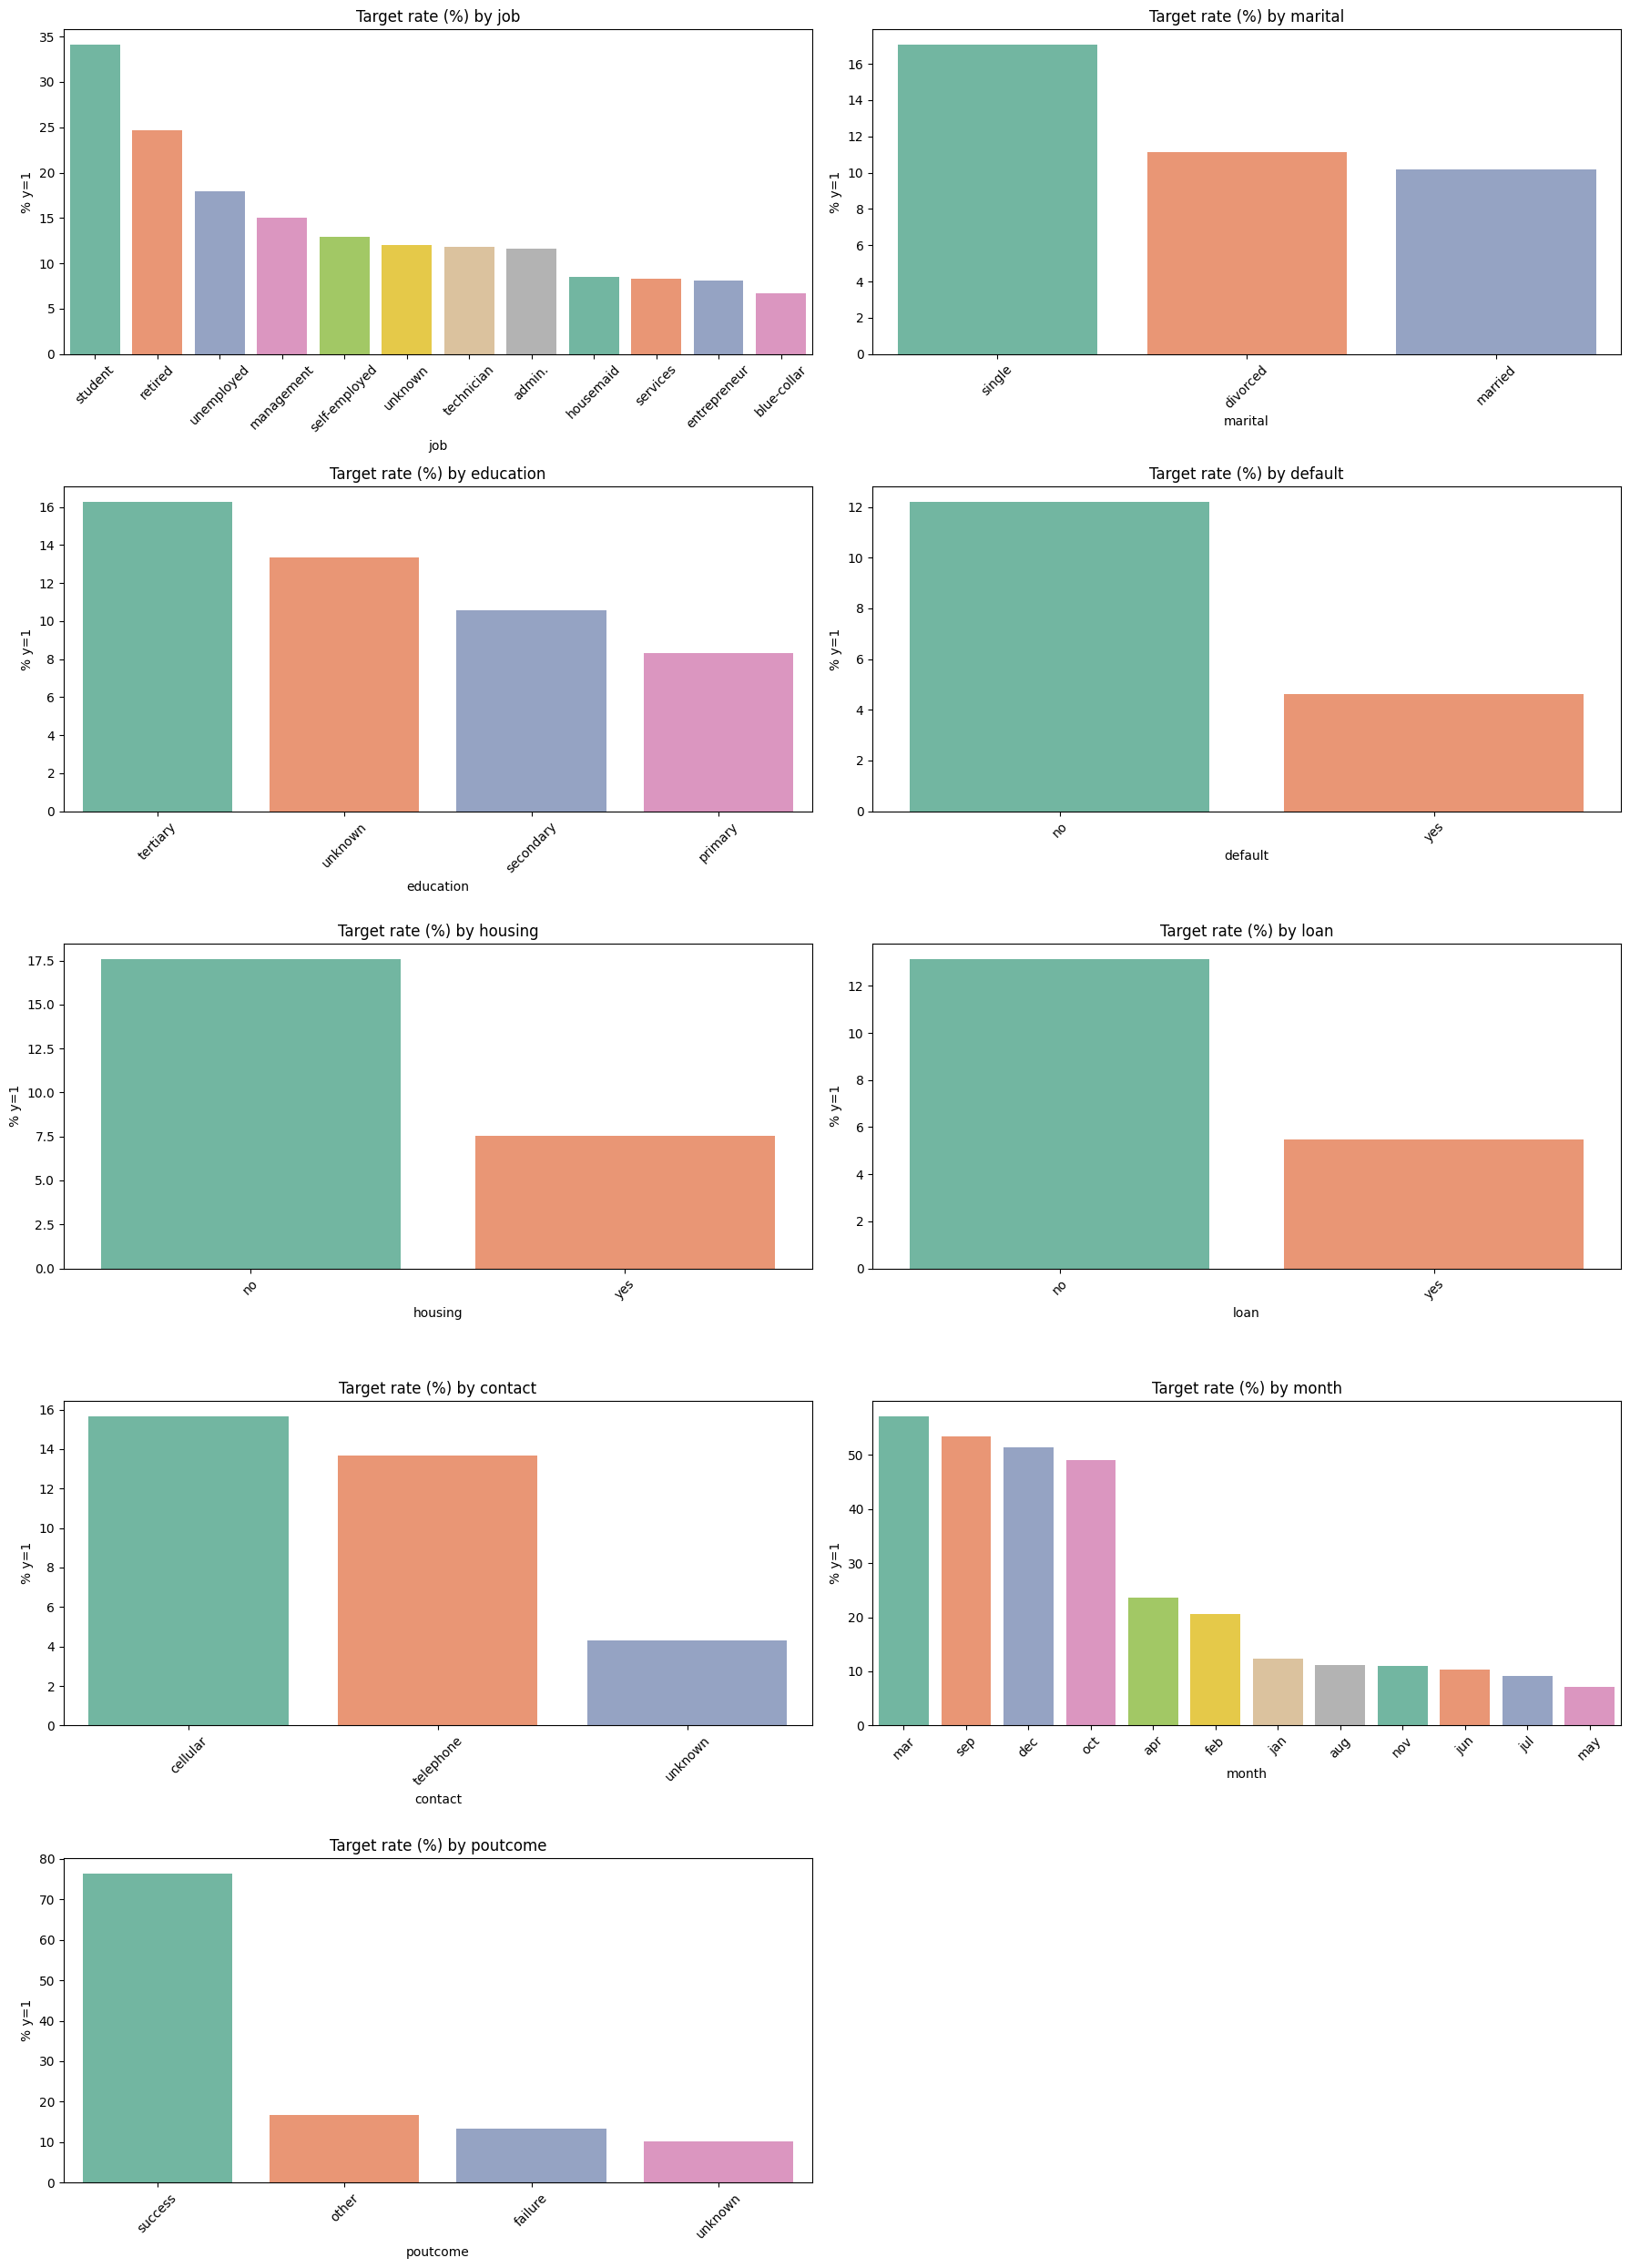

In [54]:
categorical_cols_plot = train_fe.select_dtypes(include=["object"]).columns

n_cols = 2
n_rows = (len(categorical_cols_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols_plot):
    percentages = train_fe.groupby(col)[TARGET].mean() * 100
    percentages = percentages.sort_values(ascending=False)
    sns.barplot(
        x=percentages.index, y=percentages.values,
        ax=axes[i], hue=percentages.index, palette="Set2", legend=False
    )
    axes[i].set_title(f"Target rate (%) by {col}")
    axes[i].set_ylabel("% y=1")
    if col == "job_education":
        axes[i].set_xticklabels([])
        axes[i].set_xlabel("")
    else:
        axes[i].set_xlabel(col)
        axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

---
## 6. Preprocessing Pipelines

### 6a. Skewness of Numerical Features

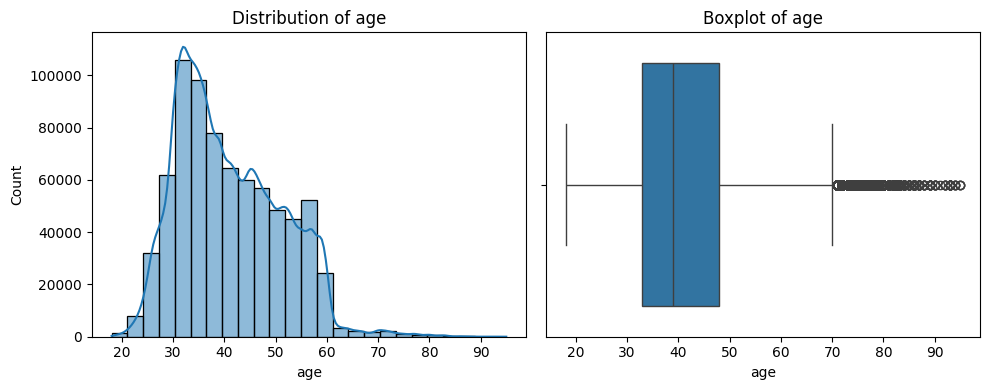

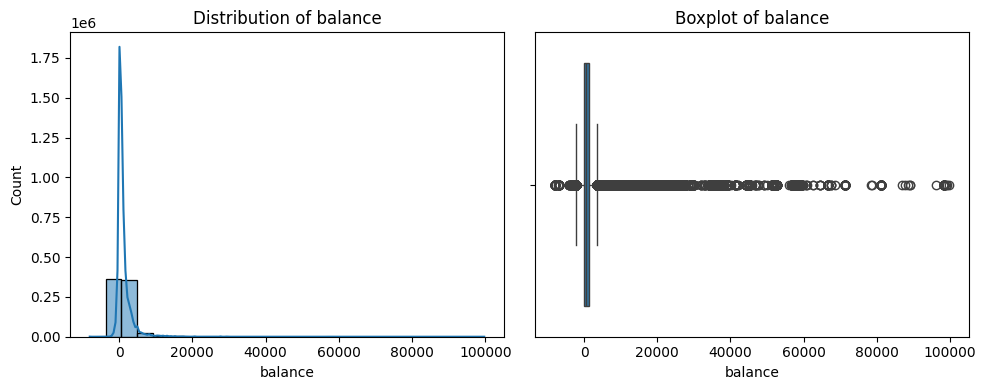

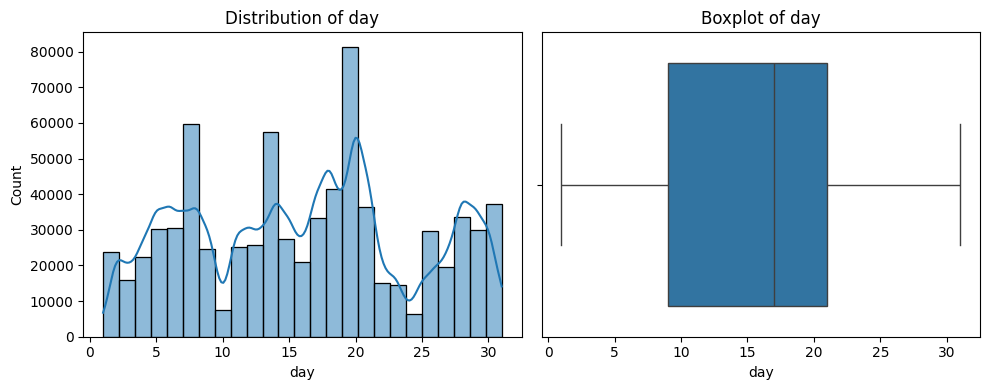

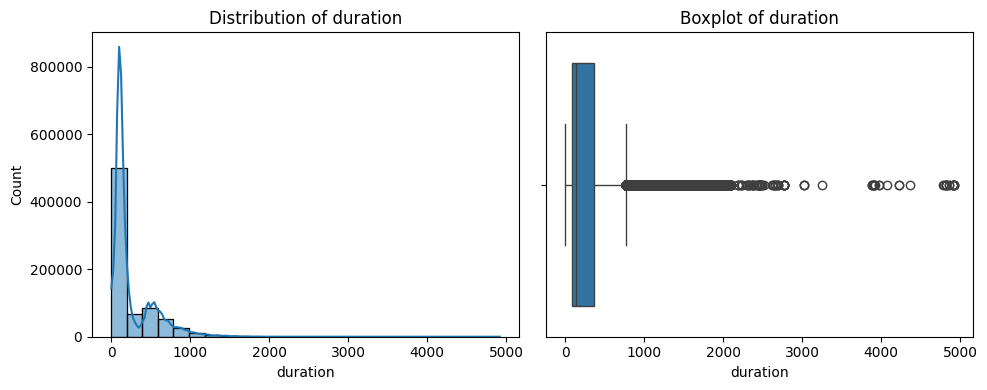

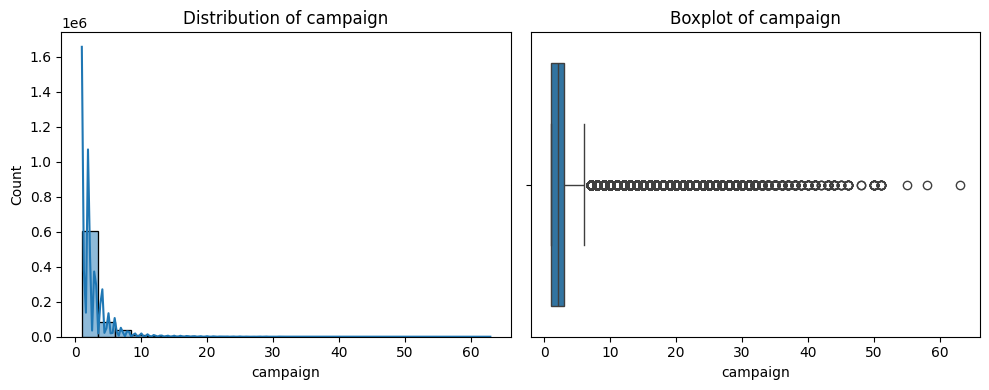

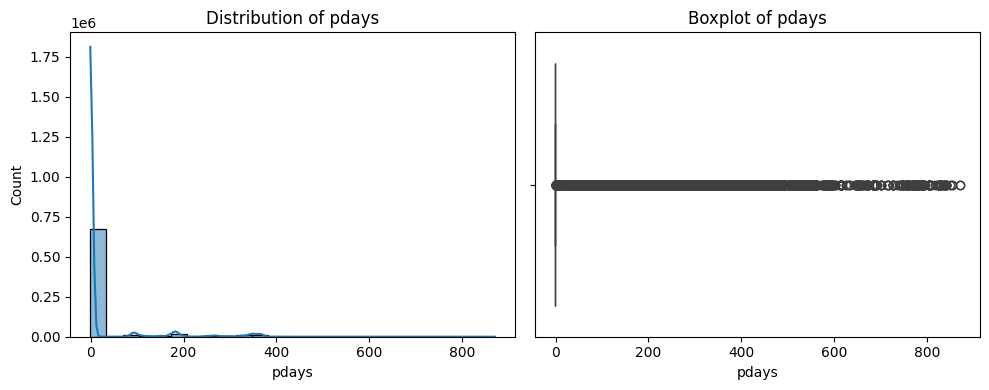

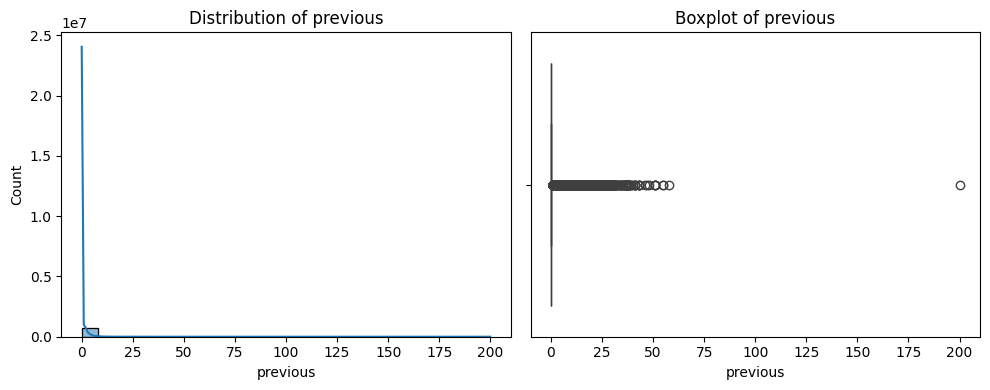

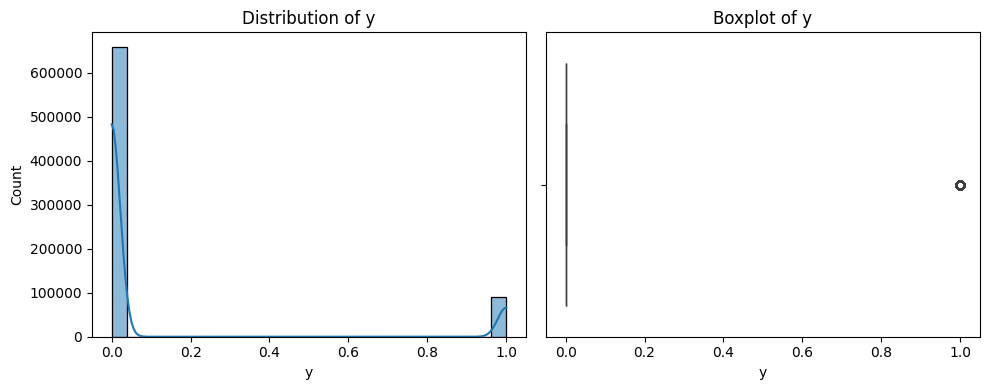

In [55]:
# Visualise distributions to decide on transformation strategy
numerical_features = train_fe.select_dtypes(include=[np.number]).columns.tolist()

for col in numerical_features:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(train_fe[col], kde=True, bins=25, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")
    sns.boxplot(x=train_fe[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

In [56]:
# we already observed skewness empirically from the plots, now let's confirm with skewness metric
skewness = train_fe[numerical_features].skew().sort_values(ascending=False)
print("Skewness of numerical features:")
print(skewness)

Skewness of numerical features:
previous    13.749885
balance     12.304123
campaign     4.810437
pdays        3.625049
y            2.329296
duration     2.048776
age          0.586137
day          0.054014
dtype: float64


Highly skewed features:
- `previous`, `campaign`, `duration` — right-skewed → log1p after clipping negatives to 0.
- `balance` — can be negative → cube-root transform.
- `pdays` — special sentinel -1 for "never contacted" → bespoke transformer.

### 6b. Feature Column Definitions

In [57]:
# Assign transformation buckets based on the selected feature set
# Base skewed cols that are always present
_BASE_LOG1P = ["campaign", "previous", "duration"]
_BASE_CBRT  = ["balance"]
_BASE_PDAYS = ["pdays"]

# Conditionally include engineered features in the right bucket
SKEWED_LOG1P = _BASE_LOG1P + (["duration_balance"] if "duration_balance" in NUMERICAL_COLS else []) \
                            + (["contact_rate"]    if "contact_rate"    in NUMERICAL_COLS else [])
SKEWED_CBRT  = _BASE_CBRT  + (["balance_per_age"]  if "balance_per_age" in NUMERICAL_COLS else [])
PDAYS_COLS   = _BASE_PDAYS

SCALE_ONLY = [
    c for c in NUMERICAL_COLS
    if c not in SKEWED_LOG1P + SKEWED_CBRT + PDAYS_COLS
]

print("SKEWED_LOG1P :", SKEWED_LOG1P)
print("SKEWED_CBRT  :", SKEWED_CBRT)
print("PDAYS_COLS   :", PDAYS_COLS)
print("SCALE_ONLY   :", SCALE_ONLY)
print("CATEGORICAL  :", CATEGORICAL_COLS)

SKEWED_LOG1P : ['campaign', 'previous', 'duration']
SKEWED_CBRT  : ['balance']
PDAYS_COLS   : ['pdays']
SCALE_ONLY   : ['age', 'day']
CATEGORICAL  : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


### 6c. Custom Transformers & Preprocessor Builder

Disclaimer: I asked ChatGPT to help me write the following picklable custom transformers for the skewed features that need special handling. When I used the 'standard' `FunctionTransformer` with a locally-defined lambda function, I ran into pickling issues (pickling means saving the fitted transformer to disk, which is necessary when using Colab or other cloud environments).

In [ ]:
# Picklable custom transformers for skewed features that need special handling
# Subclassing BaseEstimator + TransformerMixin is always pickle-safe, unlike a locally-defined closure wrapped by FunctionTransformer.

class Log1pClipper(BaseEstimator, TransformerMixin):
    """log1p after clipping negatives to 0 — safe for skewed non-negative cols."""
    def fit(self, X, y=None): return self
    def transform(self, X):   return np.log1p(np.clip(X, 0, None))


class CbrtTransformer(BaseEstimator, TransformerMixin):
    """Cube-root transform — handles negative values (e.g. balance)."""
    def fit(self, X, y=None): return self
    def transform(self, X):   return np.cbrt(X)


class PdaysTransformer(BaseEstimator, TransformerMixin):
    """pdays=-1 (never contacted) → 0; otherwise log1p."""
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = np.array(X)
        return np.where(X > -1, np.log1p(X), 0).reshape(-1, 1)


# ── Encoding strategy ─────────────────────────────────────────────────────────
# "onehot"  —> turns all categoricals into one-hot vectors; safe for all models, no leakage risk.
# "target"  —> this is actually an hybrid approach I defined as: use target encoding for high-cardinality categoricals and one-hot encoding for low-cardinality ones
    # THIS HYBRID APPROACH PROVED TO BE THE BEST

ENCODING_STRATEGY = "target"   # this works better than onehot. Change to "onehot" to experiment.

HIGH_CARD_COLS = [c for c in ["job_education", "job", "month", "poutcome"]
                  if c in CATEGORICAL_COLS]
LOW_CARD_COLS  = [c for c in CATEGORICAL_COLS if c not in HIGH_CARD_COLS]


def build_preprocessor(encoding_strategy="onehot"):
    """Return a ColumnTransformer with appropriate transforms per feature type."""

    num_transformers = [
        ("log1p",
         Pipeline([("log", Log1pClipper()), ("scale", StandardScaler())]),
         SKEWED_LOG1P),

        ("cbrt",
         Pipeline([("cbrt", CbrtTransformer()), ("scale", StandardScaler())]),
         SKEWED_CBRT),

        ("pdays",
         Pipeline([("pdays", PdaysTransformer()), ("scale", StandardScaler())]),
         PDAYS_COLS),

        ("scale_only",
         Pipeline([("impute", SimpleImputer(strategy="median")),
                   ("scale",  StandardScaler())]),
         SCALE_ONLY),
    ]

    if encoding_strategy == "onehot":
        cat_transformers = [
            ("cat_ohe",
             Pipeline([
                 ("impute", SimpleImputer(strategy="most_frequent")),
                 ("encode", OneHotEncoder(
                     handle_unknown="ignore", sparse_output=False, drop="first"
                 )),
             ]),
             CATEGORICAL_COLS),
        ]

    elif encoding_strategy == "target":
        cat_transformers = [
            ("cat_target",
             Pipeline([
                 ("impute", SimpleImputer(strategy="most_frequent")),
                 ("encode", TargetEncoder(
                     target_type="binary", smooth="auto",
                     cv=N_SPLITS, random_state=RANDOM_SEED,
                 )),
             ]),
             HIGH_CARD_COLS),

            ("cat_ohe",
             Pipeline([
                 ("impute", SimpleImputer(strategy="most_frequent")),
                 ("encode", OneHotEncoder(
                     handle_unknown="ignore", sparse_output=False, drop="first"
                 )),
             ]),
             LOW_CARD_COLS),
        ]

    else:
        raise ValueError(f"Unknown encoding_strategy: {encoding_strategy!r}")

    return ColumnTransformer(
        transformers=num_transformers + cat_transformers,
        remainder="drop",
        n_jobs=N_JOBS,
    )


preprocessor = build_preprocessor(ENCODING_STRATEGY)
print(f"Preprocessor built with encoding_strategy='{ENCODING_STRATEGY}'.")

Preprocessor built with encoding_strategy='target'.


---
## 7. Prepare X / y

In [61]:
X            = train_fe[NUMERICAL_COLS + CATEGORICAL_COLS]
y            = train_fe[TARGET]
X_test_final = test_fe[NUMERICAL_COLS + CATEGORICAL_COLS]

print("X shape:", X.shape)
print("X_test_final shape:", X_test_final.shape)

X shape: (750000, 16)
X_test_final shape: (250000, 16)


---
## 8. CV Helper

`run_cv()` runs stratified k-fold CV on any Pipeline and returns OOF predictions,
per-fold AUC scores, and averaged test-set predictions.

In [62]:
def run_cv(pipeline, X, y, X_test, n_splits=N_SPLITS, seed=RANDOM_SEED, label="Model"):
    """
    Stratified K-Fold CV.
    Returns (oof_preds, test_preds, cv_scores).
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof  = np.zeros(len(X))
    test_folds = np.zeros((n_splits, len(X_test)))
    scores = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        pipeline.fit(X_tr, y_tr)

        val_pred         = pipeline.predict_proba(X_val)[:, 1]
        oof[val_idx]     = val_pred
        test_folds[fold] = pipeline.predict_proba(X_test)[:, 1]

        fold_auc = roc_auc_score(y_val, val_pred)
        scores.append(fold_auc)
        print(f"  [{label}] Fold {fold+1}/{n_splits}  AUC={fold_auc:.5f}")

    mean_auc = np.mean(scores)
    std_auc  = np.std(scores)
    print(f"  [{label}] CV AUC = {mean_auc:.5f} ± {std_auc:.5f}")

    return oof, test_folds.mean(axis=0), scores

---
## 9. Baseline: Random Forest (no hyperparameter tuning)

A simple untuned RF gives us an anchor for the ablation study.

In [63]:
# Quick hold-out check to verify the pipeline runs end-to-end
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

baseline_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_SEED, n_jobs=N_JOBS
    ))
])

baseline_pipe.fit(X_tr, y_tr)
baseline_val_auc = roc_auc_score(y_val, baseline_pipe.predict_proba(X_val)[:, 1])
print(f"Baseline RF  val AUC (hold-out) = {baseline_val_auc:.5f}")

Baseline RF  val AUC (hold-out) = 0.96187


In [ ]:
# Full CV for baseline: used as anchor in the ablation table (step 15)
baseline_cv_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_SEED, n_jobs=N_JOBS
    ))
])

print("Running baseline CV...")
baseline_oof, baseline_test_pred, baseline_cv_scores = run_cv(
    baseline_cv_pipe, X, y, X_test_final, label="RF-Baseline"
)

Running baseline CV...
  [RF-Baseline] Fold 1/5  AUC=0.96289
  [RF-Baseline] Fold 2/5  AUC=0.96158
  [RF-Baseline] Fold 3/5  AUC=0.96203
  [RF-Baseline] Fold 4/5  AUC=0.96256
  [RF-Baseline] Fold 5/5  AUC=0.96222
  [RF-Baseline] CV AUC = 0.96225 ± 0.00045


In [ ]:
# # ── Save artefacts
# # Models are saved immediately after training so the session can be restored without full retraining if the Colab runtime disconnects.
# import os
# os.makedirs(SAVE_DIR, exist_ok=True)

# joblib.dump(baseline_cv_pipe,   SAVE_DIR + "baseline_rf_pipeline.pkl")
# joblib.dump(baseline_cv_scores, SAVE_DIR + "baseline_rf_cv_scores.pkl")
# joblib.dump(baseline_oof,       SAVE_DIR + "baseline_rf_oof.pkl")
# joblib.dump(baseline_test_pred, SAVE_DIR + "baseline_rf_test_pred.pkl")
# print("Baseline RF artefacts saved.")

Baseline RF artefacts saved.


In [ ]:
# ── LOAD (uncomment if session crashed) ──────────────────────────────────────
# baseline_cv_pipe   = joblib.load(SAVE_DIR + "baseline_rf_pipeline.pkl")
# baseline_cv_scores = joblib.load(SAVE_DIR + "baseline_rf_cv_scores.pkl")
# baseline_oof       = joblib.load(SAVE_DIR + "baseline_rf_oof.pkl")
# baseline_test_pred = joblib.load(SAVE_DIR + "baseline_rf_test_pred.pkl")
# print("Baseline RF artefacts loaded.")

---
## 10. XGBoost: Hyperparameter Tuning + CV

GridSearchCV is run on a 30 % subsample to find good hyperparameters cheaply;
the best params are then used in the full N_SPLITS-fold CV.

In [ ]:
# ── Step 1: GridSearchCV on a 30 % subsample ──────────────────────────────────
print("XGBoost: running GridSearchCV (reduced grid for Colab)...")

# this is a pretty small grid, almost just to show the process. For a real competition, I would expand it significantly and run on a larger subsample or even the full data if resources allow.
xgb_param_grid = {
    "clf__max_depth":        [5, 7],
    "clf__learning_rate":    [0.05, 0.1],
    "clf__subsample":        [0.8],
    "clf__colsample_bytree": [0.8],
}

xgb_search_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", XGBClassifier(
        objective="binary:logistic", eval_metric="auc",
        n_estimators=300, random_state=RANDOM_SEED,
        n_jobs=N_JOBS, verbosity=0, use_label_encoder=False,
    ))
])

X_gs, _, y_gs, _ = train_test_split(
    X, y, train_size=0.30, random_state=RANDOM_SEED, stratify=y
)

xgb_gs = GridSearchCV(
    xgb_search_pipe, xgb_param_grid,
    scoring="roc_auc", cv=3, n_jobs=N_JOBS, verbose=1,
)
xgb_gs.fit(X_gs, y_gs)

print("XGBoost best params:", xgb_gs.best_params_)
print(f"XGBoost best CV AUC (grid search): {xgb_gs.best_score_:.5f}")

XGBoost: running GridSearchCV (reduced grid for Colab)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
XGBoost best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 7, 'clf__subsample': 0.8}
XGBoost best CV AUC (grid search): 0.96487


In [ ]:
# Step 2: Full CV with best params
best_xgb_params = {k.replace("clf__", ""): v for k, v in xgb_gs.best_params_.items()}

xgb_cv_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", XGBClassifier(
        objective="binary:logistic", eval_metric="auc",
        n_estimators=1000, random_state=RANDOM_SEED,
        n_jobs=N_JOBS, verbosity=0, use_label_encoder=False,
        **best_xgb_params,
    ))
])

print("XGBoost: running full CV...")
xgb_oof, xgb_test_pred, xgb_cv_scores = run_cv(
    xgb_cv_pipe, X, y, X_test_final, label="XGBoost"
)

XGBoost: running full CV...
  [XGBoost] Fold 1/5  AUC=0.96831
  [XGBoost] Fold 2/5  AUC=0.96695
  [XGBoost] Fold 3/5  AUC=0.96707
  [XGBoost] Fold 4/5  AUC=0.96812
  [XGBoost] Fold 5/5  AUC=0.96754
  [XGBoost] CV AUC = 0.96760 ± 0.00055


In [ ]:
# joblib.dump(xgb_cv_pipe,   SAVE_DIR + "xgb_pipeline.pkl")
# joblib.dump(xgb_cv_scores, SAVE_DIR + "xgb_cv_scores.pkl")
# joblib.dump(xgb_oof,       SAVE_DIR + "xgb_oof.pkl")
# joblib.dump(xgb_test_pred, SAVE_DIR + "xgb_test_pred.pkl")
# print("XGBoost artefacts saved.")

XGBoost artefacts saved.


In [66]:
# #── LOAD (uncomment if session crashed) ──────────────────────────────────────
# xgb_cv_pipe   = joblib.load(SAVE_DIR + "xgb_pipeline.pkl")
# xgb_cv_scores = joblib.load(SAVE_DIR + "xgb_cv_scores.pkl")
# xgb_oof       = joblib.load(SAVE_DIR + "xgb_oof.pkl")
# xgb_test_pred = joblib.load(SAVE_DIR + "xgb_test_pred.pkl")
# print("XGBoost artefacts loaded.")

XGBoost artefacts loaded.


---
## 11. LightGBM: Hyperparameter Tuning + CV

In [ ]:
# Step 1: GridSearchCV
print("LightGBM: running GridSearchCV (reduced grid for Colab)...")

# this is a pretty small grid, almost just to show the process. For a real competition, I would expand it significantly and run on a larger subsample or even the full data if resources allow.
lgbm_param_grid = {
    "clf__num_leaves":    [31, 64],
    "clf__learning_rate": [0.05, 0.1],
    "clf__subsample":     [0.8],
}

lgbm_search_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", LGBMClassifier(
        objective="binary", metric="auc",
        n_estimators=300, random_state=RANDOM_SEED,
        n_jobs=N_JOBS, verbosity=-1,
    ))
])

lgbm_gs = GridSearchCV(
    lgbm_search_pipe, lgbm_param_grid,
    scoring="roc_auc", cv=3, n_jobs=N_JOBS, verbose=1,
)
lgbm_gs.fit(X_gs, y_gs)   # reuse the same 30 % subsample from step 10

print("LightGBM best params:", lgbm_gs.best_params_)
print(f"LightGBM best CV AUC (grid search): {lgbm_gs.best_score_:.5f}")

LightGBM: running GridSearchCV (reduced grid for Colab)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
LightGBM best params: {'clf__learning_rate': 0.05, 'clf__num_leaves': 64, 'clf__subsample': 0.8}
LightGBM best CV AUC (grid search): 0.96477


In [ ]:
# Step 2: Full CV with best params
best_lgbm_params = {k.replace("clf__", ""): v for k, v in lgbm_gs.best_params_.items()}

lgbm_cv_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", LGBMClassifier(
        objective="binary", metric="auc",
        n_estimators=1000, random_state=RANDOM_SEED,
        n_jobs=N_JOBS, verbosity=-1,
        **best_lgbm_params,
    ))
])

print("LightGBM: running full CV...")
lgbm_oof, lgbm_test_pred, lgbm_cv_scores = run_cv(
    lgbm_cv_pipe, X, y, X_test_final, label="LightGBM"
)

LightGBM: running full CV...
  [LightGBM] Fold 1/5  AUC=0.96867
  [LightGBM] Fold 2/5  AUC=0.96758
  [LightGBM] Fold 3/5  AUC=0.96764
  [LightGBM] Fold 4/5  AUC=0.96878
  [LightGBM] Fold 5/5  AUC=0.96791
  [LightGBM] CV AUC = 0.96812 ± 0.00051


In [ ]:
# joblib.dump(lgbm_cv_pipe,   SAVE_DIR + "lgbm_pipeline.pkl")
# joblib.dump(lgbm_cv_scores, SAVE_DIR + "lgbm_cv_scores.pkl")
# joblib.dump(lgbm_oof,       SAVE_DIR + "lgbm_oof.pkl")
# joblib.dump(lgbm_test_pred, SAVE_DIR + "lgbm_test_pred.pkl")
# print("LightGBM artefacts saved.")

LightGBM artefacts saved.


In [ ]:
# #── LOAD (uncomment if session crashed) ──────────────────────────────────────
# lgbm_cv_pipe   = joblib.load(SAVE_DIR + "lgbm_pipeline.pkl")
# lgbm_cv_scores = joblib.load(SAVE_DIR + "lgbm_cv_scores.pkl")
# lgbm_oof       = joblib.load(SAVE_DIR + "lgbm_oof.pkl")
# lgbm_test_pred = joblib.load(SAVE_DIR + "lgbm_test_pred.pkl")
# print("LightGBM artefacts loaded.")

LightGBM artefacts loaded.


---
## 12. Random Forest: Hyperparameter Tuning + CV

Separate from the baseline above: now with tuned hyperparameters, to be used as
a base learner in the stacking ensemble.

In [ ]:
# Step 1: GridSearchCV
print("Random Forest: running GridSearchCV (reduced grid for Colab)...")

rf_param_grid = {
    "clf__n_estimators":     [100, 200],
    "clf__max_depth":        [None, 15],
    "clf__min_samples_leaf": [1, 4],
}

rf_search_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=N_JOBS))
])

rf_gs = GridSearchCV(
    rf_search_pipe, rf_param_grid,
    scoring="roc_auc", cv=3, n_jobs=N_JOBS, verbose=1,
)
rf_gs.fit(X_gs, y_gs)

print("RF best params:", rf_gs.best_params_)
print(f"RF best CV AUC (grid search): {rf_gs.best_score_:.5f}")

Random Forest: running GridSearchCV (reduced grid for Colab)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
RF best params: {'clf__max_depth': None, 'clf__min_samples_leaf': 4, 'clf__n_estimators': 200}
RF best CV AUC (grid search): 0.96084


In [ ]:
# Step 2: Full CV with best params
best_rf_params = {k.replace("clf__", ""): v for k, v in rf_gs.best_params_.items()}

rf_tuned_cv_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(
        random_state=RANDOM_SEED, n_jobs=N_JOBS, **best_rf_params
    ))
])

print("Random Forest (tuned): running full CV...")
rf_oof, rf_test_pred, rf_cv_scores = run_cv(
    rf_tuned_cv_pipe, X, y, X_test_final, label="RF-Tuned"
)

Random Forest (tuned): running full CV...
  [RF-Tuned] Fold 1/5  AUC=0.96421
  [RF-Tuned] Fold 2/5  AUC=0.96291
  [RF-Tuned] Fold 3/5  AUC=0.96303
  [RF-Tuned] Fold 4/5  AUC=0.96380
  [RF-Tuned] Fold 5/5  AUC=0.96330
  [RF-Tuned] CV AUC = 0.96345 ± 0.00049


In [ ]:
# joblib.dump(rf_tuned_cv_pipe, SAVE_DIR + "rf_tuned_pipeline.pkl")
# joblib.dump(rf_cv_scores,     SAVE_DIR + "rf_tuned_cv_scores.pkl")
# joblib.dump(rf_oof,           SAVE_DIR + "rf_tuned_oof.pkl")
# joblib.dump(rf_test_pred,     SAVE_DIR + "rf_tuned_test_pred.pkl")
# print("RF-tuned artefacts saved.")

RF-tuned artefacts saved.


In [68]:
# #── LOAD (uncomment if session crashed) ──────────────────────────────────────
# rf_tuned_cv_pipe = joblib.load(SAVE_DIR + "rf_tuned_pipeline.pkl")
# rf_cv_scores     = joblib.load(SAVE_DIR + "rf_tuned_cv_scores.pkl")
# rf_oof           = joblib.load(SAVE_DIR + "rf_tuned_oof.pkl")
# rf_test_pred     = joblib.load(SAVE_DIR + "rf_tuned_test_pred.pkl")
# print("RF-tuned artefacts loaded.")

RF-tuned artefacts loaded.


---
## 13. Stacking Ensemble

Logistic Regression meta-learner trained on OOF predictions from XGBoost + LightGBM + Random Forest (tuned).

We also train a second meta-learner using only XGBoost + LightGBM (no RF) to test whether the RF adds value or introduces noise. Sometimes it can happen that a weak model actually hurts the ensemble by adding noise, so it's important to verify.

In [69]:
# Meta-feature matrices: stack OOF preds from the 3 base models
Z_train = np.column_stack([xgb_oof, lgbm_oof, rf_oof])
Z_test  = np.column_stack([xgb_test_pred, lgbm_test_pred, rf_test_pred])

# XGB + LGBM only (no RF) — tested separately in step 15
Z_train_no_rf = np.column_stack([xgb_oof, lgbm_oof])
Z_test_no_rf  = np.column_stack([xgb_test_pred, lgbm_test_pred])

print("Meta-feature matrix (train, 3 base models):", Z_train.shape)
print("Meta-feature matrix (test,  3 base models):", Z_test.shape)

Meta-feature matrix (train, 3 base models): (750000, 3)
Meta-feature matrix (test,  3 base models): (250000, 3)


In [ ]:
# 13a. Stacking with all 3 base models (XGB + LGBM + RF)
skf_meta = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
meta_oof       = np.zeros(len(y))
meta_cv_scores = []

print("Training Stacking meta-learner (XGB + LGBM + RF → LR)...")

for fold, (tr_idx, val_idx) in enumerate(skf_meta.split(Z_train, y)):
    meta_model = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_SEED)
    meta_model.fit(Z_train[tr_idx], y.iloc[tr_idx])
    val_pred             = meta_model.predict_proba(Z_train[val_idx])[:, 1]
    meta_oof[val_idx]    = val_pred
    fold_auc = roc_auc_score(y.iloc[val_idx], val_pred)
    meta_cv_scores.append(fold_auc)
    print(f"  [Stacking-3] Fold {fold+1}/{N_SPLITS}  AUC={fold_auc:.5f}")

print(f"  [Stacking-3] CV AUC = {np.mean(meta_cv_scores):.5f} ± {np.std(meta_cv_scores):.5f}")

# Final meta-model trained on full data
meta_model_full = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_SEED)
meta_model_full.fit(Z_train, y)
test_pred_meta = meta_model_full.predict_proba(Z_test)[:, 1]

Training Stacking meta-learner (XGB + LGBM + RF → LR)...
  [Stacking-3] Fold 1/5  AUC=0.96891
  [Stacking-3] Fold 2/5  AUC=0.96766
  [Stacking-3] Fold 3/5  AUC=0.96770
  [Stacking-3] Fold 4/5  AUC=0.96876
  [Stacking-3] Fold 5/5  AUC=0.96813
  [Stacking-3] CV AUC = 0.96823 ± 0.00052


In [ ]:
# 13b. Stacking WITHOUT Random Forest (XGB + LGBM only)
# Used in ablation step E to check whether the RF adds value or noise to the ensemble.
meta_no_rf_oof       = np.zeros(len(y))
meta_no_rf_cv_scores = []

print("Training Stacking meta-learner (XGB + LGBM → LR, no RF)...")

for fold, (tr_idx, val_idx) in enumerate(skf_meta.split(Z_train_no_rf, y)):
    meta_model = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_SEED)
    meta_model.fit(Z_train_no_rf[tr_idx], y.iloc[tr_idx])
    val_pred                    = meta_model.predict_proba(Z_train_no_rf[val_idx])[:, 1]
    meta_no_rf_oof[val_idx]     = val_pred
    fold_auc = roc_auc_score(y.iloc[val_idx], val_pred)
    meta_no_rf_cv_scores.append(fold_auc)
    print(f"  [Stacking-NoRF] Fold {fold+1}/{N_SPLITS}  AUC={fold_auc:.5f}")

print(f"  [Stacking-NoRF] CV AUC = {np.mean(meta_no_rf_cv_scores):.5f} ± {np.std(meta_no_rf_cv_scores):.5f}")

# Final meta-model for this variant
meta_no_rf_full = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_SEED)
meta_no_rf_full.fit(Z_train_no_rf, y)
test_pred_meta_no_rf = meta_no_rf_full.predict_proba(Z_test_no_rf)[:, 1]

Training Stacking meta-learner (XGB + LGBM → LR, no RF)...
  [Stacking-NoRF] Fold 1/5  AUC=0.96930
  [Stacking-NoRF] Fold 2/5  AUC=0.96810
  [Stacking-NoRF] Fold 3/5  AUC=0.96817
  [Stacking-NoRF] Fold 4/5  AUC=0.96930
  [Stacking-NoRF] Fold 5/5  AUC=0.96851
  [Stacking-NoRF] CV AUC = 0.96867 ± 0.00053


In [ ]:
# # Save all stacking artefacts
# joblib.dump(meta_model_full,         SAVE_DIR + "meta_model.pkl")
# joblib.dump(meta_cv_scores,          SAVE_DIR + "meta_cv_scores.pkl")
# joblib.dump(meta_oof,                SAVE_DIR + "meta_oof.pkl")
# joblib.dump(test_pred_meta,          SAVE_DIR + "test_pred_meta.pkl")
# joblib.dump(meta_no_rf_full,         SAVE_DIR + "meta_no_rf_model.pkl")
# joblib.dump(meta_no_rf_cv_scores,    SAVE_DIR + "meta_no_rf_cv_scores.pkl")
# joblib.dump(meta_no_rf_oof,          SAVE_DIR + "meta_no_rf_oof.pkl")
# joblib.dump(test_pred_meta_no_rf,    SAVE_DIR + "test_pred_meta_no_rf.pkl")
# print("Stacking artefacts saved.")

Stacking artefacts saved.


In [73]:
# ── LOAD (uncomment if session crashed) ──────────────────────────────────────
# meta_model_full      = joblib.load(SAVE_DIR + "meta_model.pkl")
# meta_cv_scores       = joblib.load(SAVE_DIR + "meta_cv_scores.pkl")
# meta_oof             = joblib.load(SAVE_DIR + "meta_oof.pkl")
# test_pred_meta       = joblib.load(SAVE_DIR + "test_pred_meta.pkl")
# meta_no_rf_full      = joblib.load(SAVE_DIR + "meta_no_rf_model.pkl")
# meta_no_rf_cv_scores = joblib.load(SAVE_DIR + "meta_no_rf_cv_scores.pkl")
# meta_no_rf_oof       = joblib.load(SAVE_DIR + "meta_no_rf_oof.pkl")
# test_pred_meta_no_rf = joblib.load(SAVE_DIR + "test_pred_meta_no_rf.pkl")
# print("Stacking artefacts loaded.")

---
## 14. Final Model Comparison Table

In [74]:
def fmt(scores):
    """Return 'mean ± std' string from a list of fold scores."""
    return f"{np.mean(scores):.5f} ± {np.std(scores):.5f}"

comparison_data = [
    {"Model": "Random Forest (baseline)",          "CV ROC-AUC (mean ± std)": fmt(baseline_cv_scores),     "Notes": "Default params, no tuning"},
    {"Model": "Random Forest (tuned)",             "CV ROC-AUC (mean ± std)": fmt(rf_cv_scores),            "Notes": "GridSearchCV on max_depth, n_est, min_samples_leaf"},
    {"Model": "XGBoost (tuned)",                   "CV ROC-AUC (mean ± std)": fmt(xgb_cv_scores),           "Notes": "GridSearchCV on max_depth, lr, subsample"},
    {"Model": "LightGBM (tuned)",                  "CV ROC-AUC (mean ± std)": fmt(lgbm_cv_scores),          "Notes": "GridSearchCV on num_leaves, lr, subsample"},
    {"Model": "Stacking (XGB+LGBM+RF → LR)",      "CV ROC-AUC (mean ± std)": fmt(meta_cv_scores),          "Notes": "LR meta-learner on OOF from all 3 base models"},
    {"Model": "Stacking (XGB+LGBM → LR, no RF)",  "CV ROC-AUC (mean ± std)": fmt(meta_no_rf_cv_scores),    "Notes": "LR meta-learner on OOF from XGB + LGBM only"},
]

comparison_df = pd.DataFrame(comparison_data)
print("=== Model Comparison Table ===")
comparison_df

=== Model Comparison Table ===


,Model,CV ROC-AUC (mean ± std),Notes
0,Random Forest (baseline),0.96225 ± 0.00045,"Default params, no tuning"
1,Random Forest (tuned),0.96345 ± 0.00049,"GridSearchCV on max_depth, n_est, min_samples_..."
2,XGBoost (tuned),0.96760 ± 0.00055,"GridSearchCV on max_depth, lr, subsample"
3,LightGBM (tuned),0.96812 ± 0.00051,"GridSearchCV on num_leaves, lr, subsample"
4,Stacking (XGB+LGBM+RF → LR),0.96823 ± 0.00052,LR meta-learner on OOF from all 3 base models
5,"Stacking (XGB+LGBM → LR, no RF)",0.96867 ± 0.00053,LR meta-learner on OOF from XGB + LGBM only


As expected:
- the tuned random forest outperforms the untuned version by a good margin.
- XGBoost and LightGBM are better than RF, as they are based on boosting, which is often more powerful than bagging (RF).
- Stacking multiple models gives a better ROC-AUC than any single model, confirming the value of ensembling.


---
## 15. Ablation Study

Incremental contribution of each modelling decision:

| Step | What changes |
|---|---|
| A | Baseline RF, raw features, default params |
| B | + Best feature engineering set (raw / v1 / v2, selected in step 5) |
| C | + Naive ensemble (simple mean of tuned XGB + LGBM + RF OOF) |
| D | + Learned stacking with all 3 base models (XGB + LGBM + RF → LR) |
| E | Learned stacking without RF (XGB + LGBM → LR) — isolates RF contribution |

In [75]:
# ── Ablation Step A: Baseline RF on raw features (no FE, no tuning) ──────────
pre_no_fe = ColumnTransformer(
    transformers=[
        ("scale",
         Pipeline([("impute", SimpleImputer(strategy="median")),
                   ("scale",  StandardScaler())]),
         RAW_NUM_COLS),
        ("cat_ohe",
         Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                   ("encode", OneHotEncoder(
                       handle_unknown="ignore", sparse_output=False, drop="first"
                   ))]),
         RAW_CAT_COLS),
    ],
    remainder="drop",
)

ablation_baseline_pipe = Pipeline([
    ("pre", pre_no_fe),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=N_JOBS))
])

X_no_fe = train[RAW_NUM_COLS + RAW_CAT_COLS]

print("Ablation — Step A: Baseline (no FE, no tuning)...")
abl_a_scores = cross_val_score(
    ablation_baseline_pipe, X_no_fe, y,
    cv=StratifiedKFold(N_SPLITS, shuffle=True, random_state=RANDOM_SEED),
    scoring="roc_auc", n_jobs=N_JOBS,
)
print(f"  AUC = {np.mean(abl_a_scores):.5f} ± {np.std(abl_a_scores):.5f}")

Ablation — Step A: Baseline (no FE, no tuning)...
  AUC = 0.96117 ± 0.00062


In [76]:
# ── Ablation Step B: + Best Feature Engineering ───────────────────────────────
# baseline_cv_scores was computed on X which already uses the selected FE set
print(f"Ablation — Step B: + Feature Engineering ({FE_VERSION}) — AUC = {fmt(baseline_cv_scores)}")

Ablation — Step B: + Feature Engineering (raw) — AUC = 0.96225 ± 0.00045


In [77]:
# ── Ablation Step C: + Naive Ensemble (simple mean of tuned base-model OOFs) ──
naive_ens_oof    = (xgb_oof + lgbm_oof + rf_oof) / 3.0
naive_ens_scores = []

skf_ablation = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
for fold, (_, val_idx) in enumerate(skf_ablation.split(X, y)):
    fold_auc = roc_auc_score(y.iloc[val_idx], naive_ens_oof[val_idx])
    naive_ens_scores.append(fold_auc)
    print(f"  [Naive Ensemble] Fold {fold+1}/{N_SPLITS}  AUC={fold_auc:.5f}")

print(f"Ablation — Step C: + Naive Ensemble (mean XGB/LGBM/RF) — AUC = {fmt(naive_ens_scores)}")

  [Naive Ensemble] Fold 1/5  AUC=0.96891
  [Naive Ensemble] Fold 2/5  AUC=0.96762
  [Naive Ensemble] Fold 3/5  AUC=0.96765
  [Naive Ensemble] Fold 4/5  AUC=0.96872
  [Naive Ensemble] Fold 5/5  AUC=0.96812
Ablation — Step C: + Naive Ensemble (mean XGB/LGBM/RF) — AUC = 0.96820 ± 0.00053


In [78]:
# ── Ablation Step D: + Learned Stacking (XGB + LGBM + RF → LR) ───────────────
# Already computed in step 13a
print(f"Ablation — Step D: + Learned Stacking (XGB+LGBM+RF → LR) — AUC = {fmt(meta_cv_scores)}")

Ablation — Step D: + Learned Stacking (XGB+LGBM+RF → LR) — AUC = 0.96823 ± 0.00052


In [79]:
# ── Ablation Step E: Learned Stacking WITHOUT Random Forest ───────────────────
# Already computed in step 13b. Compared against step C (naive ensemble)
# rather than step D, to test whether dropping the RF from the stack
# can recover the advantage of the naive ensemble.
print(f"Ablation — Step E: Learned Stacking (XGB+LGBM → LR, no RF) — AUC = {fmt(meta_no_rf_cv_scores)}")

Ablation — Step E: Learned Stacking (XGB+LGBM → LR, no RF) — AUC = 0.96867 ± 0.00053


In [82]:
ablation_data = [
    {
        "Step": "A — Baseline (RF, default params, no FE)",
        "CV ROC-AUC (mean ± std)": fmt(abl_a_scores),
        "Delta vs prev.": "—"
    },
    {
        "Step": f"B — + Feature Engineering / Preprocessing ({FE_VERSION})",
        "CV ROC-AUC (mean ± std)": fmt(baseline_cv_scores),
        "Delta vs prev.": f"{np.mean(baseline_cv_scores) - np.mean(abl_a_scores):+.5f}"
    },
    {
        "Step": "C — + Naive Ensemble (mean of XGB / LGBM / RF)",
        "CV ROC-AUC (mean ± std)": fmt(naive_ens_scores),
        "Delta vs prev.": f"{np.mean(naive_ens_scores) - np.mean(baseline_cv_scores):+.5f}"
    },
    {
        "Step": "D — + Learned Stacking (XGB + LGBM + RF → LR)",
        "CV ROC-AUC (mean ± std)": fmt(meta_cv_scores),
        "Delta vs prev.": f"{np.mean(meta_cv_scores) - np.mean(naive_ens_scores):+.5f}",
        "Delta vs naive ens. (C)": f"{np.mean(meta_cv_scores) - np.mean(naive_ens_scores):+.5f}"
    },
    {
        "Step": "E — Learned Stacking (XGB + LGBM → LR, no RF)",
        "CV ROC-AUC (mean ± std)": fmt(meta_no_rf_cv_scores),
        "Delta vs prev.": f"{np.mean(meta_no_rf_cv_scores) - np.mean(meta_cv_scores):+.5f}",
        # Delta is against the naive ensemble (step C) — more informative than vs D
        "Delta vs naive ens. (C)": f"{np.mean(meta_no_rf_cv_scores) - np.mean(naive_ens_scores):+.5f}"
    },
]

ablation_df = pd.DataFrame(ablation_data)
print("=== Ablation Study Table ===")
ablation_df

=== Ablation Study Table ===


,Step,CV ROC-AUC (mean ± std),Delta vs prev.,Delta vs naive ens. (C)
0,"A — Baseline (RF, default params, no FE)",0.96117 ± 0.00062,—,NaN
1,B — + Feature Engineering / Preprocessing (raw),0.96225 ± 0.00045,+0.00109,NaN
2,C — + Naive Ensemble (mean of XGB / LGBM / RF),0.96820 ± 0.00053,+0.00595,NaN
3,D — + Learned Stacking (XGB + LGBM + RF → LR),0.96823 ± 0.00052,+0.00003,+0.00003
4,"E — Learned Stacking (XGB + LGBM → LR, no RF)",0.96867 ± 0.00053,+0.00044,+0.00047


Even if small, we see increments at each step (as expected). The Random Forest, which is a weaker model compared to the others, indeed adds noise to the ensemble, as the stacking performance without RF is better than with RF.

---
## 16. Submission File

Use predictions from the best model identified in the comparison table above.
By default we use the 3-model stacking ensemble; swap `test_pred_meta` for
`test_pred_meta_no_rf` or a single-model pred if the ablation study favours it.

In [81]:
# Pick the best predictions based on ablation results
all_preds = {
    "xgb":           (xgb_test_pred,          xgb_cv_scores),
    "lgbm":          (lgbm_test_pred,          lgbm_cv_scores),
    "rf_tuned":      (rf_test_pred,            rf_cv_scores),
    "naive_ensemble": ((xgb_test_pred + lgbm_test_pred + rf_test_pred) / 3.0, naive_ens_scores),
    "stack_3":       (test_pred_meta,          meta_cv_scores),
    "stack_no_rf":   (test_pred_meta_no_rf,    meta_no_rf_cv_scores),
}

best_key  = max(all_preds, key=lambda k: np.mean(all_preds[k][1]))
best_preds, best_scores = all_preds[best_key]
print(f"Best model by CV AUC: {best_key}  ({fmt(best_scores)})")

sub = submission.copy()
sub["y"] = best_preds
sub.to_csv("submission.csv", index=False)

print("submission.csv written.")
sub.head()

Best model by CV AUC: stack_no_rf  (0.96867 ± 0.00053)
submission.csv written.


,id,y
0,750000,0.018144
1,750001,0.037680
2,750002,0.018008
3,750003,0.017982
4,750004,0.020529
